# Paso 3 — ML Model
Feature matrix → XGBoost + spatial block CV → flood probability raster → aggregate to ARBA parcels.

In [1]:
import sys
sys.path.insert(0, '..')
from src.config import load_config
from src.features import build_pixel_features, aggregate_to_parcels
from src.model import train_model, predict_raster
from src.viz import plot_raster
from pathlib import Path

cfg = load_config()
proc = Path('../data/processed')
outputs = Path('../outputs')
outputs.mkdir(exist_ok=True)

## 3.1 Build feature matrix

In [2]:
feature_rasters = {
    'twi':      proc / 'twi.tif',
    'flow_acc': proc / 'flow_acc.tif',
    'slope':    proc / 'slope.tif',
    # water_rel_elev excluded — derived from flood_freq_combined, same as target
    # Add soil type, NDVI, CHIRPS accumulations when available
}

df = build_pixel_features(
    raster_paths=feature_rasters,
    flood_target_path=Path('../data/raw/flood_freq_combined.tif'),
)
print(df.shape)
df.head()

(500000, 6)


,x,y,twi,flow_acc,slope,flooded
6204800,-62.923056,-34.878611,4.857852,4.054955,2.248426,0
484730,-62.390000,-34.437222,3.237169,1.000000,4.491353,0
3041384,-62.405556,-34.634444,3.781337,1.000000,2.609987,0
957695,-62.047222,-34.473611,2.587519,2.489758,14.705734,0
3399463,-62.966944,-34.662222,6.826895,21.237089,1.381127,0


## 3.2 Train with spatial block CV

In [3]:
feature_cols = [c for c in df.columns if c not in ('flooded', 'x', 'y')]
model, cv_results = train_model(
    df=df,
    feature_cols=feature_cols,
    target_col='flooded',
    n_blocks=cfg['model']['n_spatial_blocks'],
    xgb_params=cfg['model']['xgboost_params'],
    output_dir=str(outputs),
)
cv_results

Block 0: AUC=0.668, AP=0.235


Block 1: AUC=0.768, AP=0.414


Block 2: AUC=0.795, AP=0.539


Block 3: AUC=0.690, AP=0.341


Block 4: AUC=0.632, AP=0.131

Mean AUC = 0.711 ± 0.069
Mean AP  = 0.332 ± 0.158


,block,AUC,AP,n_train,n_test
0,0,0.668184,0.234791,399937,100063
1,1,0.768087,0.413774,401005,98995
2,2,0.794891,0.539052,399801,100199
3,3,0.690412,0.341215,399555,100445
4,4,0.631741,0.130681,399702,100298


## 3.3 Probability raster

Probability raster saved: ../outputs/flood_probability.tif


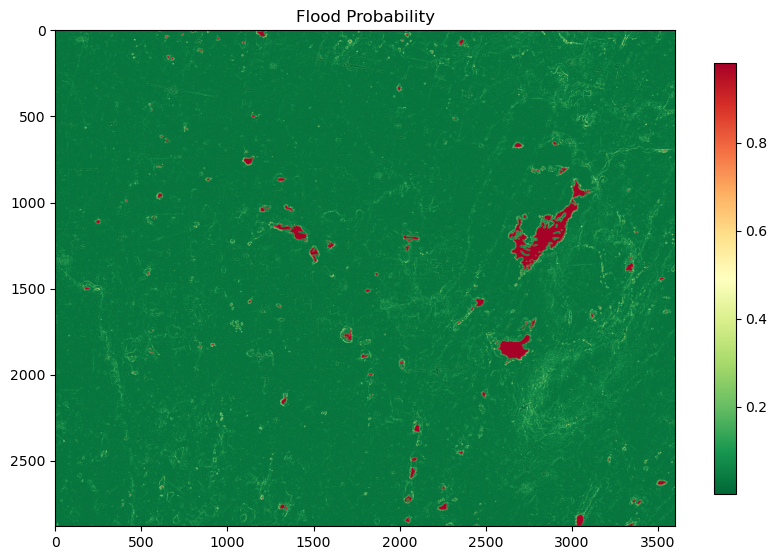

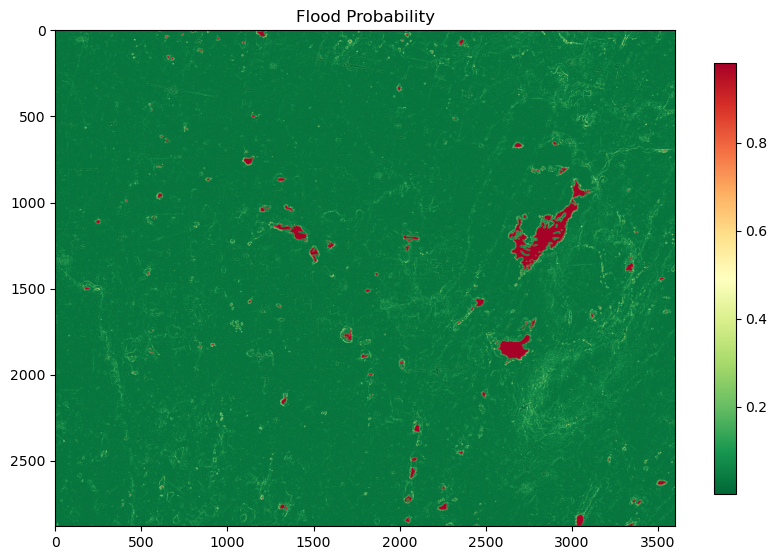

In [4]:
predict_raster(
    model=model,
    feature_raster_paths=feature_rasters,
    output_path=outputs / 'flood_probability.tif',
    feature_cols=feature_cols,
    ref_raster_path=proc / 'twi.tif',
)
plot_raster(outputs / 'flood_probability.tif',
            title='Flood Probability', cmap='RdYlGn_r',
            output_path=str(outputs / 'flood_prob_map.png'))

## 3.4 Aggregate to ARBA parcels
Adjust path once catastro ARBA shapefile is downloaded.

In [5]:
arba_path = Path('../data/raw/arba_parcelas.shp')  # download from ARBA
if arba_path.exists():
    parcel_features = aggregate_to_parcels(
        feature_raster_paths={
            'flood_prob': outputs / 'flood_probability.tif',
            'twi': proc / 'twi.tif',
        },
        parcel_shapefile=str(arba_path),
        output_path=str(outputs / 'parcel_flood_risk.gpkg'),
    )
else:
    print('ARBA shapefile not found. Download from https://www.arba.gov.ar (catastro).')

ARBA shapefile not found. Download from https://www.arba.gov.ar (catastro).
